# Chapter 15 - Orbit Correction

While operating an accelerator, the beam orbit is measured at selected locations with beam position monitors (BPMs). The design orbit is often chosen so the ideal BPM readings are zero, but a real machine may instead use a measured reference orbit, often called a golden orbit. Orbit correction changes the beam trajectory so the BPM readings approach the desired values.

In this SciBmad notebook, a BPM is represented as a zero-length `Marker`: it gives us a named location where the orbit can be read. A corrector is represented as a `Kicker`: it can apply a small transverse kick and therefore changes the downstream orbit.


In [ ]:
using Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()


In [2]:
using SciBmad
using CairoMakie
using GTPSA
using LinearAlgebra
using Statistics
using Printf


## 15.1 Adding Corrector Coils and BPMs

We start from the original example ring lattice and add two kinds of elements:

- horizontal correctors near focusing quadrupoles;
- vertical correctors near defocusing quadrupoles;
- BPM markers after dipoles, where the orbit will be sampled.

To make room for a corrector inside the `D1` drift, split the baseline `0.609 m` drift into three pieces:

| Piece | Role | Length |
|---|---|---:|
| `D1C1` | short drift before or after the corrector | `0.064 m` |
| `CH` or `CV` | horizontal or vertical corrector | `0.2 m` |
| `D1C2` | remaining drift | `0.345 m` |

The total length is unchanged: `0.064 + 0.2 + 0.345 = 0.609 m`.


In [3]:
const CH14_SPECIES = Species("electron")
const CH14_E_REF = 1.7846262612447e10

const D1_TOTAL = 0.609
const D1C1_L = 0.064
const CORRECTOR_L = 0.2
const D1C2_L = D1_TOTAL - D1C1_L - CORRECTOR_L

@assert isapprox(D1C1_L + CORRECTOR_L + D1C2_L, D1_TOTAL)

function d1c1(name="D1C1")
    return Drift(name=name, L=D1C1_L)
end

function d1c2(name="D1C2")
    return Drift(name=name, L=D1C2_L)
end

function horizontal_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function vertical_corrector(name)
    return Kicker(name=name, L=CORRECTOR_L)
end

function bpm(name)
    return Marker(name=name)
end


bpm (generic function with 1 method)

The placement follows the FODO-cell optics. In a forward cell, the horizontal corrector is placed just after the focusing quadrupole, and the vertical corrector is placed just after the defocusing quadrupole. In a reverse cell, the order is mirrored, so the corrector appears before the corresponding quadrupole.

The example below writes this directly as SciBmad element lists for one forward and one reverse FODO cell.


In [4]:
function forward_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        d1c1("D1C1_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c2("D1C2_QF" * suffix),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        Drift(name="D2" * suffix, L=1.241),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        d1c1("D1C1_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c2("D1C2_QD" * suffix),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        Drift(name="D2_END" * suffix, L=1.241),
    ]
end

function reverse_fodo_with_correctors(; suffix="")
    return [
        Quadrupole(name="QF" * suffix, L=0.5, Kn1=0.312808574467162),
        Drift(name="D2" * suffix, L=1.241),
        SBend(name="B1" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B1" * suffix),
        d1c2("D1C2_QD" * suffix),
        vertical_corrector("CV" * suffix),
        d1c1("D1C1_QD" * suffix),
        Quadrupole(name="QD" * suffix, L=0.5, Kn1=-0.312643401293818),
        Drift(name="D2_MID" * suffix, L=1.241),
        SBend(name="B2" * suffix, L=6.86016190935103, g_ref=3.46929776000413e-3, Kn0=3.46929776000413e-3),
        bpm("BPM_B2" * suffix),
        d1c2("D1C2_QF" * suffix),
        horizontal_corrector("CH" * suffix),
        d1c1("D1C1_QF" * suffix),
    ]
end

forward_cell = Beamline(
    forward_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)

reverse_cell = Beamline(
    reverse_fodo_with_correctors();
    species_ref=CH14_SPECIES,
    E_ref=CH14_E_REF,
)


Beamline:
 species_ref = electron
 E_ref = 1.7846262612447e10

  Index   Name      Kind         s [m]   
  1       QF        Quadrupole   0
  2       D2        Drift        0.5
  3       B1        SBend        1.741
  4       BPM_B1    Marker       8.60116
  5       D1C2_QD   Drift        8.60116
  6       CV        Kicker       8.94616
  7       D1C1_QD   Drift        9.14616
  8       QD        Quadrupole   9.21016
  9       D2_MID    Drift        9.71016
  10      B2        SBend        10.9512
  11      BPM_B2    Marker       17.8113
  12      D1C2_QF   Drift        17.8113
  13      CH        Kicker       18.1563
  14      D1C1_QF   Drift        18.3563


For a quick check, print the sequence of elements and the running longitudinal position. The BPM rows are the orbit readback locations; the `CH` and `CV` rows are the correctors that later orbit-correction routines can vary.


In [5]:
function element_kind(element)
    return last(split(string(typeof(element)), "."))
end

function element_length(element)
    return hasproperty(element, :L) ? element.L : 0.0
end

function show_lattice_structure(elements)
    @printf("%5s  %-14s  %-14s  %9s  %9s
", "idx", "name", "kind", "L [m]", "s [m]")
    s = 0.0
    for (idx, element) in enumerate(elements)
        L = element_length(element)
        s += L
        @printf("%5d  %-14s  %-14s  %9.3f  %9.3f
", idx, string(element.name), element_kind(element), L, s)
    end
end

show_lattice_structure(forward_cell.line)


  idx  name            kind                L [m]      s [m]
    1  QF              LineElement         0.500      0.500
    2  D1C1_QF         LineElement         0.064      0.564
    3  CH              LineElement         0.200      0.764
    4  D1C2_QF         LineElement         0.345      1.109
    5  B1              LineElement         6.860      7.969
    6  BPM_B1          LineElement         0.000      7.969
    7  D2              LineElement         1.241      9.210
    8  QD              LineElement         0.500      9.710
    9  D1C1_QD         LineElement         0.064      9.774
   10  CV              LineElement         0.200      9.974
   11  D1C2_QD         LineElement         0.345     10.319
   12  B2              LineElement         6.860     17.179
   13  BPM_B2          LineElement         0.000     17.179
   14  D2_END          LineElement         1.241     18.420


The useful separation is:

- `Marker` BPMs do not affect tracking. They are named places where we can sample the orbit.
- `Kicker` correctors are active beamline elements. Changing their kick strengths changes the downstream trajectory.
- The same insertion pattern can be repeated throughout the full ring: forward arcs, reverse arcs, dispersion suppressors, and straight sections.

This sets up the ingredients needed for orbit correction: measured orbit values at BPMs and adjustable kick strengths at correctors.


In [6]:
function bpm_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "BPM")]
end

function corrector_names(elements)
    return [string(element.name) for element in elements if startswith(string(element.name), "CH") || startswith(string(element.name), "CV")]
end

println("Forward-cell BPMs:       ", join(bpm_names(forward_cell.line), ", "))
println("Forward-cell correctors: ", join(corrector_names(forward_cell.line), ", "))


Forward-cell BPMs:       BPM_B1, BPM_B2
Forward-cell correctors: CH, CV


## 15.2 Radiation-Induced Sawtooth Orbit Correction

Synchrotron radiation causes electrons to lose energy as they travel through the ring. The RF cavities restore that energy, so the particle energy varies around the ring instead of staying perfectly constant. Since the horizontal closed orbit depends on the local momentum error, this energy variation creates a sawtooth-like horizontal orbit.

Here we use the Chapter 15.2 `ring0.bmad` ring from the tutorial files. The `BPM` marker is defined there but is not inserted throughout the expanded line, so in this notebook we use the exits of the `SBend` elements as BPM-like readback locations.


### 15.2.1 Loading and Plotting `ring0`

Start by loading the SciBmad beamline generated from `ring0.bmad`. We turn on deterministic radiation, compute the closed orbit with `twiss`, and read the horizontal orbit at the BPM readback locations.


In [15]:
function chapter15_notebook_file(parts...)
    candidates = [
        joinpath(pwd(), parts...),
        joinpath(pwd(), "Ring_Design_Tutorial_SciBmad", parts...),
        joinpath(dirname(pwd()), "Ring_Design_Tutorial_SciBmad", parts...),
    ]

    for candidate in candidates
        isfile(candidate) && return candidate
    end

    error("Could not find file: " * joinpath(parts...))
end

include(chapter15_notebook_file(
    "lattices", "chapter_15", "15_1_before_optimization", "chapter15_b_sawtooth_ring0_beamline.jl"
))

function ch15_scalar_value(x)
    try
        return Float64(x)
    catch
        return Float64(x[])
    end
end

function ch15_enable_deterministic_radiation!(ring; order=2)
    tm = Yoshida(order=order, radiation_damping_on=true, radiation_fluctuations_on=false)
    foreach(ele -> ele.tracking_method = tm, ring.line)
    return ring
end

function ch15_twiss_orbit(ring)
    table = twiss(ring).table
    return (;
        table,
        s = Float64.(table.s),
        x = ch15_scalar_value.(table.orbit_x),
        pz = ch15_scalar_value.(table.orbit_pz),
    )
end

function ch15_sbend_bpm_rows(ring, table)
    return [
        row for row in eachindex(table.beamline_index)
        if table.beamline_index[row] > 0 && ring.line[table.beamline_index[row]].kind == "SBend"
    ]
end

function ch15_orbit_stats(values)
    return (;
        rms = sqrt(mean(abs2, values)),
        peak_to_peak = maximum(values) - minimum(values),
        min = minimum(values),
        max = maximum(values),
    )
end


ch15_orbit_stats (generic function with 1 method)

In [16]:
ring0 = deepcopy(CH15_B_SAWTOOTH_RING0)
ch15_enable_deterministic_radiation!(ring0)

orbit_before_correction = ch15_twiss_orbit(ring0)
bpm_rows = ch15_sbend_bpm_rows(ring0, orbit_before_correction.table)
bpm_s = orbit_before_correction.s[bpm_rows]
x_before_correction = orbit_before_correction.x[bpm_rows]

ch_indices = findall(ele -> ele.kind == "HKicker", ring0.line)
ch_names = String.(getproperty.(ring0.line[ch_indices], :name))
ch_s = Float64.(getproperty.(ring0.line[ch_indices], :s))
cv_indices = findall(ele -> ele.kind == "VKicker", ring0.line)

before_correction_stats = ch15_orbit_stats(x_before_correction)

@printf("Loaded ring elements:        %d\n", length(ring0.line))
@printf("BPM readback points:         %d\n", length(bpm_rows))
@printf("Horizontal correctors:       %d\n", length(ch_indices))
@printf("Vertical correctors:         %d\n", length(cv_indices))
@printf("Initial BPM orbit rms:       %.6f mm\n", 1e3 * before_correction_stats.rms)
@printf("Initial BPM peak-to-peak:    %.6f mm\n", 1e3 * before_correction_stats.peak_to_peak)


Loaded ring elements:        3152
BPM readback points:         288
Horizontal correctors:       207
Vertical correctors:         206
Initial BPM orbit rms:       0.201761 mm
Initial BPM peak-to-peak:    0.916399 mm


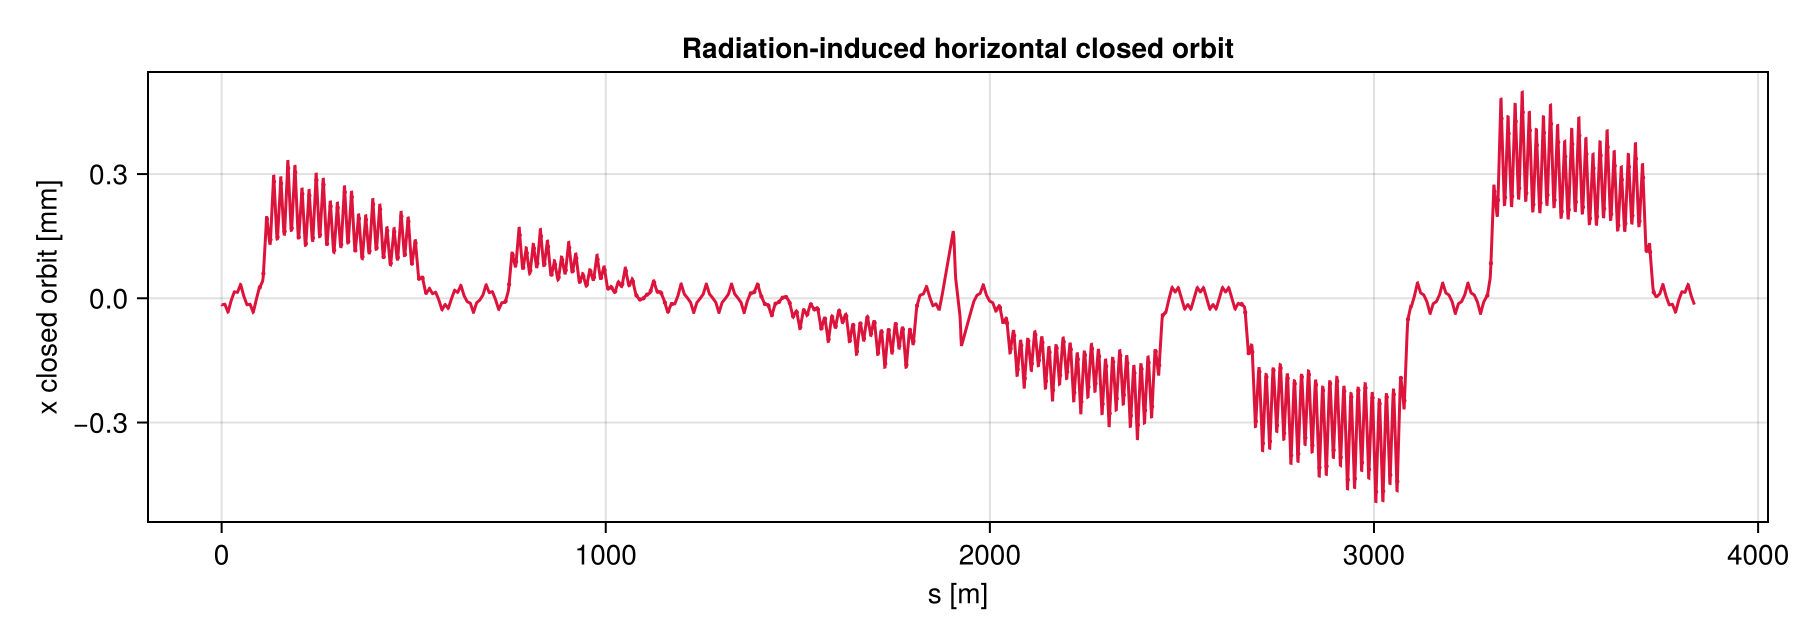

In [17]:
fig = Figure(size=(900, 320))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x closed orbit [mm]", title="Radiation-induced horizontal closed orbit")
lines!(ax, orbit_before_correction.s, 1e3 .* orbit_before_correction.x; color=:crimson, linewidth=1.5)
scatter!(ax, bpm_s, 1e3 .* x_before_correction; color=:crimson, markersize=3)
fig


### 15.2.2 Tapering

Tapering corrects the sawtooth effect by changing magnet strengths according to the local energy around the ring. With deterministic radiation on, we first compute the closed orbit and read the local momentum offset `p_z(s)` from the SciBmad `twiss` table. The magnet strength is then rescaled by

$$
K_{new} = K_{old} \frac{1 + p_{z, magnet}}{1 + \langle p_z\rangle}
$$

This is the faster alternative to treating every magnet strength as a separate optimization variable. The momentum offset is the input used to compute the taper scale, so it is not expected to become flat after tapering. The quantity to inspect is the resulting closed orbit, especially the horizontal sawtooth orbit `x(s)`.

Here we apply the taper scale to the magnetic strengths that set the ring optics: `SBend.Kn0` and `SBend.g_ref`, `Quadrupole.Kn1`, and nonzero `Sextupole.Kn2`. Corrector kickers are deliberately left unchanged, because those are reserved for orbit correction.


In [18]:
function ch15_taper_magnets_from_pz!(ring, table, pz)
    pz_average = mean(pz)

    tapered_indices = Int[]
    tapered_names = String[]
    tapered_kinds = String[]
    tapered_attributes = String[]
    tapered_s = Float64[]
    pz_at_magnet = Float64[]
    taper_scale = Float64[]
    strength_before = Float64[]
    strength_after = Float64[]

    for (idx, ele) in pairs(ring.line)
        row = findfirst(==(idx), table.beamline_index)
        row === nothing && continue

        scale = (1 + pz[row]) / (1 + pz_average)
        attribute = nothing
        old_strength = nothing

        if ele.kind == "SBend"
            old_strength = ch15_scalar_value(ele.Kn0)
            ele.Kn0 = old_strength * scale
            ele.g_ref = ch15_scalar_value(ele.g_ref) * scale
            attribute = "Kn0 and g_ref"
        elseif ele.kind == "Quadrupole"
            old_strength = ch15_scalar_value(ele.Kn1)
            ele.Kn1 = old_strength * scale
            attribute = "Kn1"
        elseif ele.kind == "Sextupole"
            old_strength = ch15_scalar_value(ele.Kn2)
            if iszero(old_strength)
                continue
            end
            ele.Kn2 = old_strength * scale
            attribute = "Kn2"
        else
            continue
        end

        push!(tapered_indices, idx)
        push!(tapered_names, String(ele.name))
        push!(tapered_kinds, String(ele.kind))
        push!(tapered_attributes, attribute)
        push!(tapered_s, Float64(table.s[row]))
        push!(pz_at_magnet, pz[row])
        push!(taper_scale, scale)
        push!(strength_before, old_strength)
        push!(strength_after, old_strength * scale)
    end

    return (;
        tapered_indices,
        tapered_names,
        tapered_kinds,
        tapered_attributes,
        tapered_s,
        pz_at_magnet,
        pz_average,
        taper_scale,
        strength_before,
        strength_after,
    )
end

ring_without_radiation = deepcopy(CH15_B_SAWTOOTH_RING0)
no_radiation = ch15_twiss_orbit(ring_without_radiation)

ring_with_taper = deepcopy(CH15_B_SAWTOOTH_RING0)
ch15_enable_deterministic_radiation!(ring_with_taper)
before_taper = ch15_twiss_orbit(ring_with_taper)

taper_result = ch15_taper_magnets_from_pz!(
    ring_with_taper,
    before_taper.table,
    before_taper.pz,
)

after_taper = ch15_twiss_orbit(ring_with_taper)

taper_kind_counts = Dict(
    kind => count(==(kind), taper_result.tapered_kinds)
    for kind in unique(taper_result.tapered_kinds)
)

taper_summary = (;
    no_radiation_pz = ch15_orbit_stats(no_radiation.pz),
    radiation_pz_before_taper = ch15_orbit_stats(before_taper.pz),
    radiation_pz_after_taper = ch15_orbit_stats(after_taper.pz),
    orbit_x_before_taper = ch15_orbit_stats(before_taper.table.orbit_x),
    orbit_x_after_taper = ch15_orbit_stats(after_taper.table.orbit_x),
    n_magnets_tapered = length(taper_result.tapered_names),
    n_sbends_tapered = get(taper_kind_counts, "SBend", 0),
    n_quadrupoles_tapered = get(taper_kind_counts, "Quadrupole", 0),
    n_sextupoles_tapered = get(taper_kind_counts, "Sextupole", 0),
    taper_scale_range = extrema(taper_result.taper_scale),
    largest_relative_scale_change = maximum(abs.(taper_result.taper_scale .- 1)),
)

@printf("No-radiation pz peak-to-peak:      %.6e
", taper_summary.no_radiation_pz.peak_to_peak)
@printf("Radiation pz peak-to-peak:         %.6e
", taper_summary.radiation_pz_before_taper.peak_to_peak)
@printf("After-taper pz peak-to-peak:       %.6e
", taper_summary.radiation_pz_after_taper.peak_to_peak)
@printf("Orbit x rms before taper:          %.6f mm
", 1e3 * sqrt(mean(abs2, before_taper.table.orbit_x)))
@printf("Orbit x rms after taper:           %.6f mm
", 1e3 * sqrt(mean(abs2, after_taper.table.orbit_x)))
@printf("Orbit x peak-to-peak before taper: %.6f mm
", 1e3 * taper_summary.orbit_x_before_taper.peak_to_peak)
@printf("Orbit x peak-to-peak after taper:  %.6f mm
", 1e3 * taper_summary.orbit_x_after_taper.peak_to_peak)
@printf("Magnets tapered:                   %d
", taper_summary.n_magnets_tapered)
@printf("  SBends:                          %d
", taper_summary.n_sbends_tapered)
@printf("  Quadrupoles:                     %d
", taper_summary.n_quadrupoles_tapered)
@printf("  Sextupoles:                      %d
", taper_summary.n_sextupoles_tapered)
@printf("Scale factor range:                %.9f to %.9f
", taper_summary.taper_scale_range...)
@printf("Largest relative strength change:  %.3e
", taper_summary.largest_relative_scale_change)


No-radiation pz peak-to-peak:      2.158908e-14
Radiation pz peak-to-peak:         1.665154e-03
After-taper pz peak-to-peak:       1.665156e-03
Orbit x rms before taper:          0.175936 mm
Orbit x rms after taper:           0.176016 mm
Orbit x peak-to-peak before taper: 0.988046 mm
Orbit x peak-to-peak after taper:  0.991851 mm
Quadrupoles tapered:               428
Scale factor range:                0.999164972 to 1.000830120
Largest relative Kn1 change:       8.350e-04


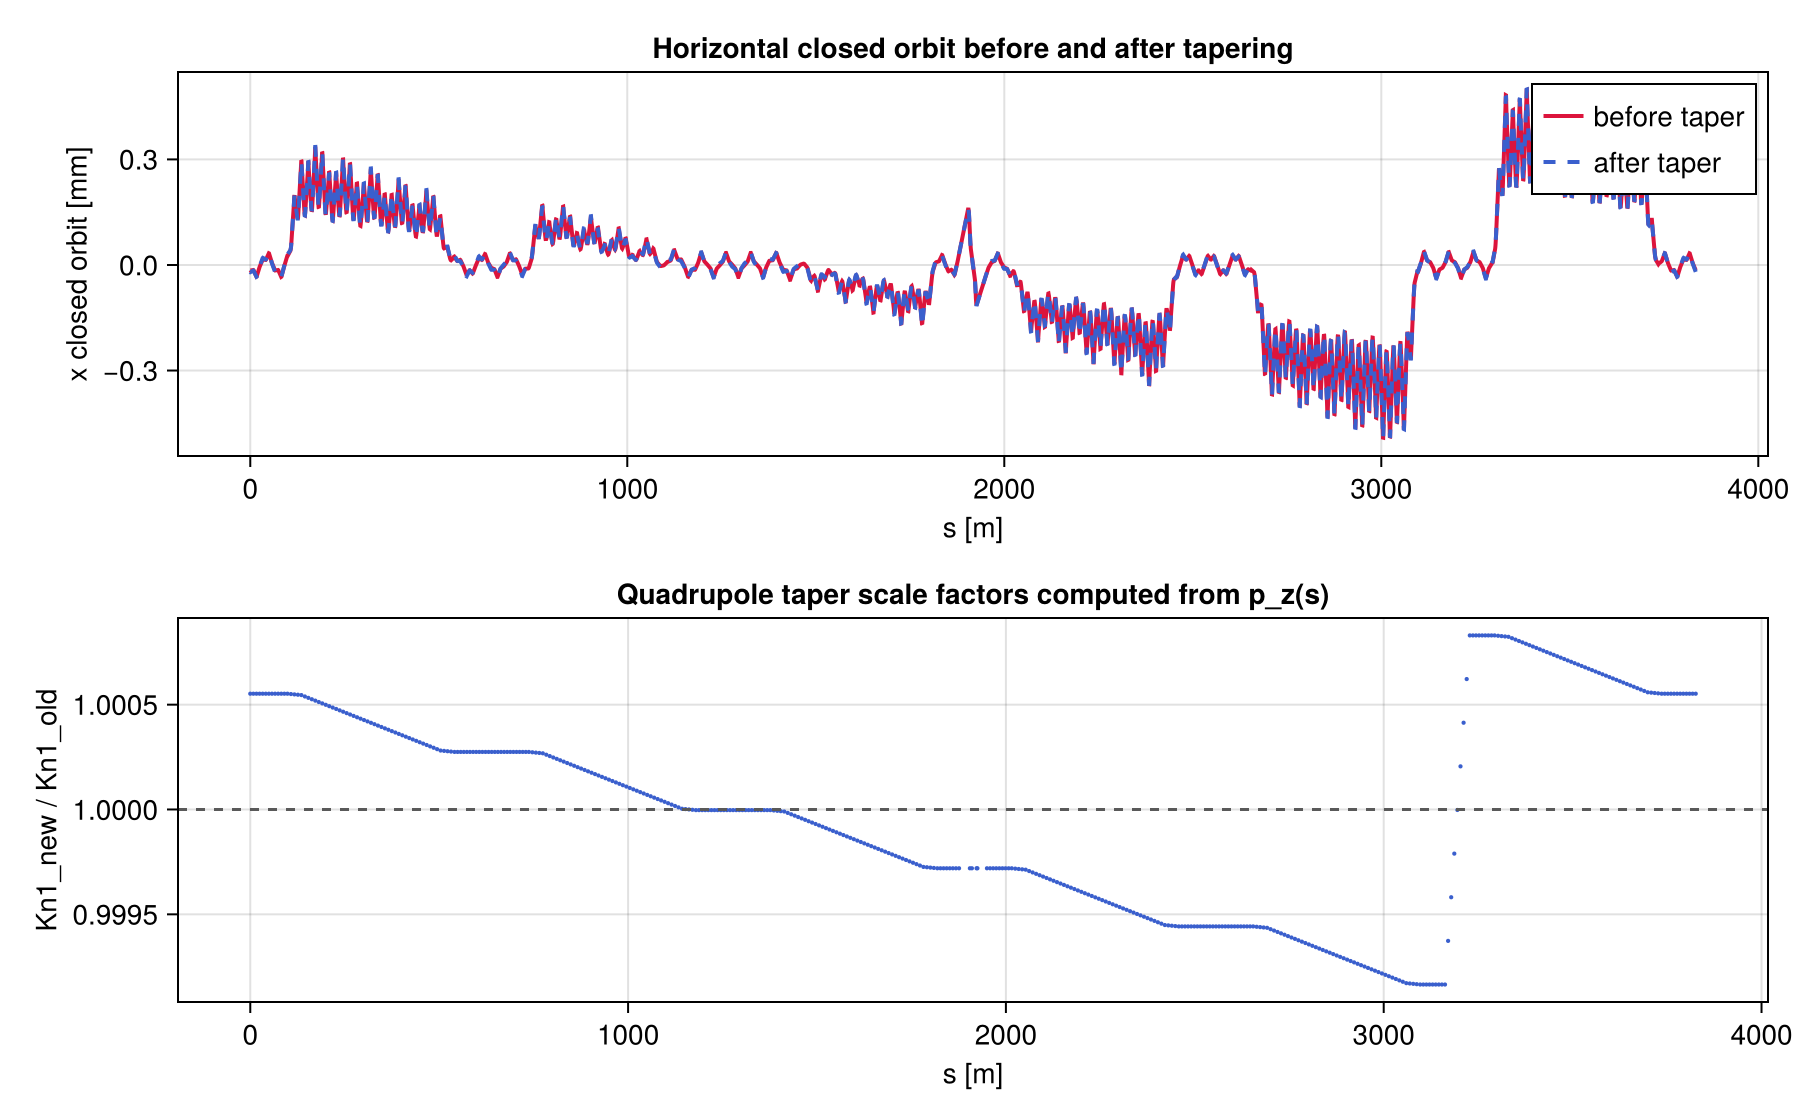

In [19]:
fig = Figure(size=(900, 560))

ax1 = Axis(
    fig[1, 1],
    xlabel="s [m]",
    ylabel="x closed orbit [mm]",
    title="Horizontal closed orbit before and after tapering",
)
lines!(ax1, before_taper.table.s, 1e3 .* before_taper.table.orbit_x; color=:crimson, linewidth=2, label="before taper")
lines!(ax1, after_taper.table.s, 1e3 .* after_taper.table.orbit_x; color=:royalblue3, linewidth=2, linestyle=:dash, label="after taper")
axislegend(ax1; position=:rt)

ax2 = Axis(
    fig[2, 1],
    xlabel="s [m]",
    ylabel="K_new / K_old",
    title="Magnet taper scale factors computed from p_z(s)",
)
scatter!(
    ax2,
    taper_result.tapered_s,
    taper_result.taper_scale;
    color=taper_result.tapered_kinds,
    markersize=3,
)
hlines!(ax2, [1.0]; color=:gray35, linestyle=:dash)

fig


### 15.2.3 Correcting the Sawtooth Orbit with Horizontal Correctors

Now use the BPM readings as the data to correct and the horizontal corrector strengths as variables. The response matrix is computed directly from the ring with GTPSA. Each corrector kick is introduced as a first-order GTPSA parameter, `twiss` propagates those parameters through the closed-orbit calculation, and the coefficient of each parameter in the BPM orbit gives one column of the response matrix.

For a large number of correctors, we build the matrix in blocks. Each block uses a descriptor

```julia
Descriptor(6, 1, n_block, 1)
```

where the first six variables are the phase-space coordinates and the `n_block` parameters are the corrector-strength derivatives requested in that block. Then solve the regularized least-squares problem

$$
R k \approx -x_{BPM}.
$$

Here `R` is the GTPSA response matrix, `k` is the vector of horizontal corrector kicks, and `x_BPM` is the radiation-induced horizontal closed orbit at the BPM readback points.


In [22]:
function ch15_horizontal_response_matrix(ring, bpm_rows, ch_indices; block_size=32)
    response = zeros(length(bpm_rows), length(ch_indices))

    for block_start in 1:block_size:length(ch_indices)
        block_stop = min(block_start + block_size - 1, length(ch_indices))
        ch_block = ch_indices[block_start:block_stop]

        # The descriptor has six phase-space variables plus one parameter for each
        # corrector strength derivative in this block.
        descriptor = Descriptor(6, 1, length(ch_block), 1)
        kick_parameters = @params(descriptor, dynamic=true)

        gtpsa_ring = deepcopy(ring)
        for (j, ch_idx) in enumerate(ch_block)
            gtpsa_ring.line[ch_idx].Kn0L =
                TPS64(gtpsa_ring.line[ch_idx].Kn0L, use=descriptor) + kick_parameters[j]
        end

        gtpsa_table = twiss(gtpsa_ring, GTPSA_descriptor=descriptor).table

        response[:, block_start:block_stop] .= [
            gtpsa_table.orbit_x[bpm_rows[i]][params=[j => 1]]
            for i in eachindex(bpm_rows), j in eachindex(ch_block)
        ]

        @printf("Computed GTPSA response columns %d:%d / %d\n",
            block_start, block_stop, length(ch_indices))
    end

    return response
end


ch15_horizontal_response_matrix (generic function with 1 method)

#### Build Response Matrix And Correct Orbit

This cell computes the response matrix with GTPSA blocks. The regularization prevents the linear solve from requesting very large kicks that would push the closed-orbit search into an unstable region.


In [23]:
response = ch15_horizontal_response_matrix(
    ring0,
    bpm_rows,
    ch_indices;
    block_size=32,
)

regularization = 0.1
ch_kicks = -(response' * response + regularization * I) \
    (response' * x_before_correction)

corrected_ring = deepcopy(ring0)
for (ch_idx, kick) in zip(ch_indices, ch_kicks)
    corrected_ring.line[ch_idx].Kn0L += kick
end

orbit_after_correction = ch15_twiss_orbit(corrected_ring)
x_after_correction = orbit_after_correction.x[bpm_rows]
after_correction_stats = ch15_orbit_stats(x_after_correction)

@printf("Initial BPM orbit rms:       %.6f mm\n", 1e3 * before_correction_stats.rms)
@printf("Corrected BPM orbit rms:     %.6f mm\n", 1e3 * after_correction_stats.rms)
@printf("Initial BPM peak-to-peak:    %.6f mm\n", 1e3 * before_correction_stats.peak_to_peak)
@printf("Corrected BPM peak-to-peak:  %.6f mm\n", 1e3 * after_correction_stats.peak_to_peak)
@printf("Largest horizontal kick:     %.3e rad\n", maximum(abs, ch_kicks))


Computed GTPSA response columns 1:32 / 207
Computed GTPSA response columns 33:64 / 207
Computed GTPSA response columns 65:96 / 207
Computed GTPSA response columns 97:128 / 207
Computed GTPSA response columns 129:160 / 207
Computed GTPSA response columns 161:192 / 207
Computed GTPSA response columns 193:207 / 207
Initial BPM orbit rms:       0.201761 mm
Corrected BPM orbit rms:     0.014644 mm
Initial BPM peak-to-peak:    0.916399 mm
Corrected BPM peak-to-peak:  0.065180 mm
Largest horizontal kick:     3.039e-05 rad


#### Plot Correction Result

The first plot compares the closed orbit before and after correction. The second plot shows the optimized horizontal corrector strengths.


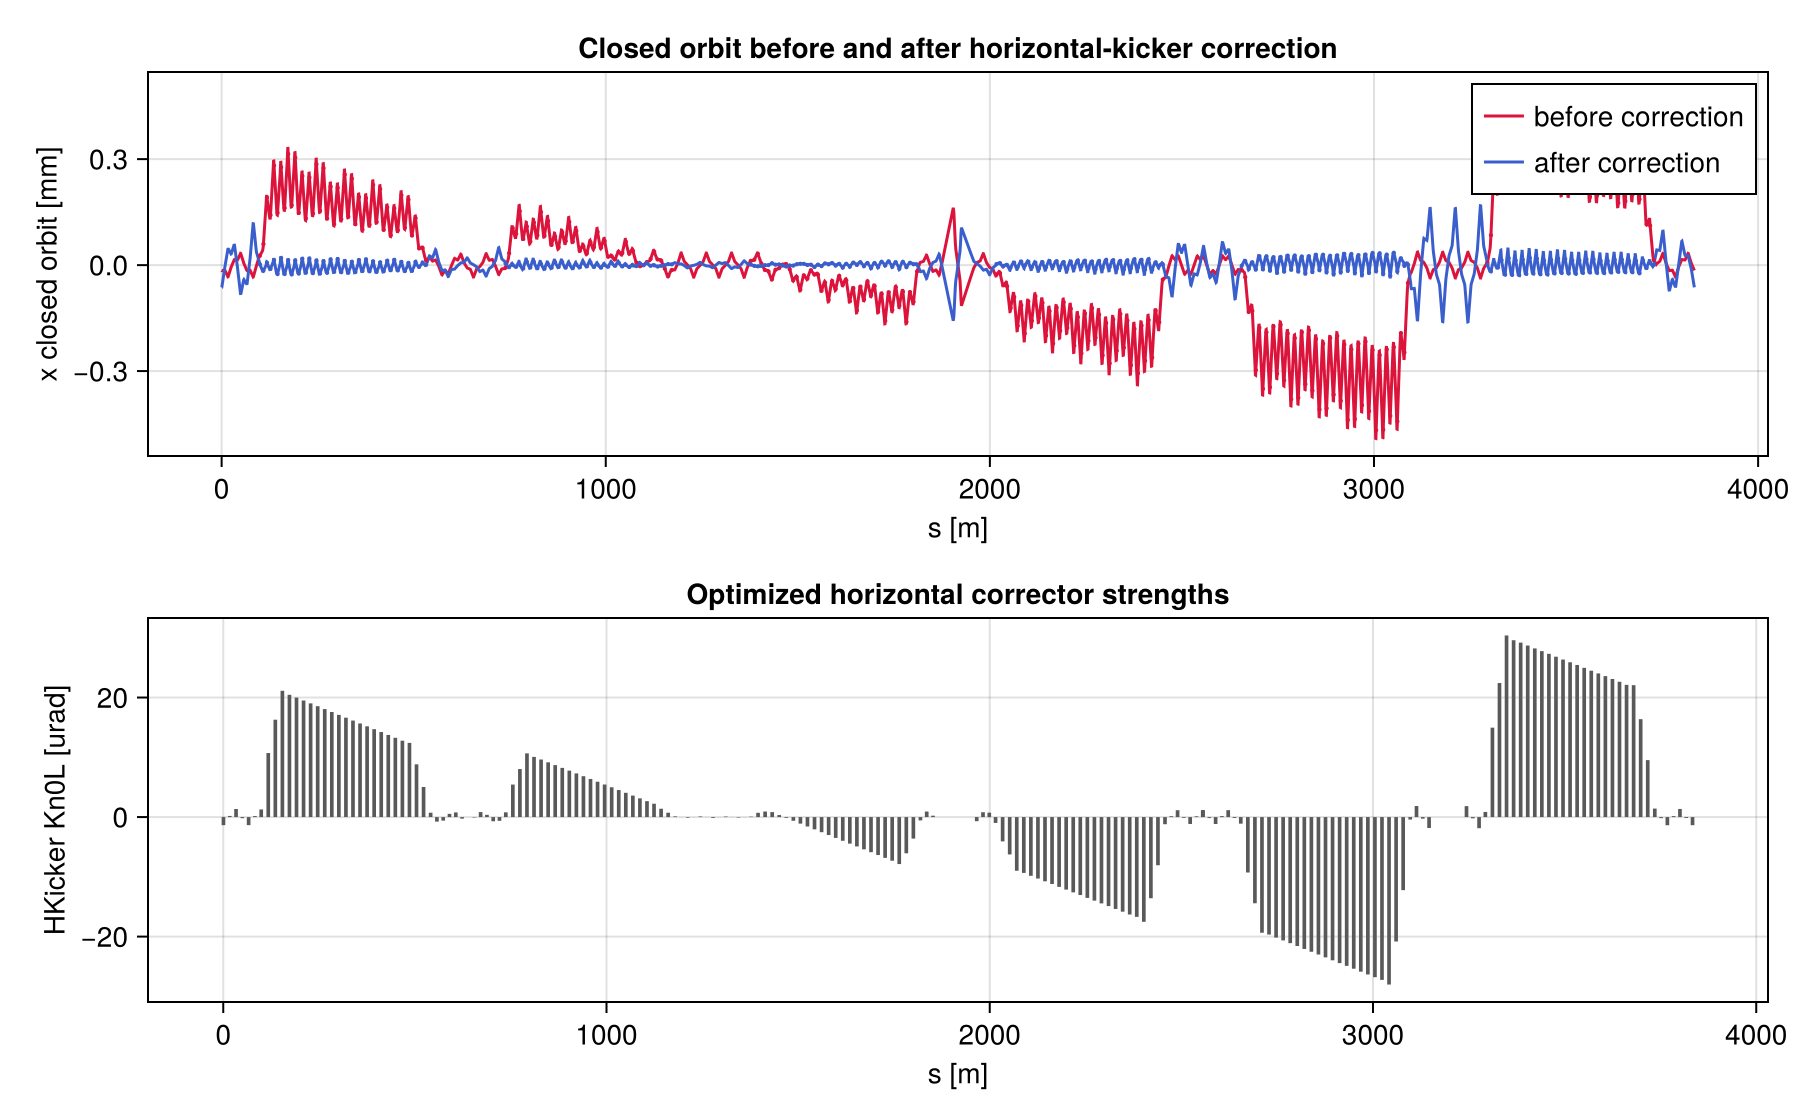

In [24]:
fig = Figure(size=(900, 560))

ax1 = Axis(fig[1, 1], xlabel="s [m]", ylabel="x closed orbit [mm]", title="Closed orbit before and after horizontal-kicker correction")
lines!(ax1, orbit_before_correction.s, 1e3 .* orbit_before_correction.x; color=:crimson, linewidth=1.5, label="before correction")
lines!(ax1, orbit_after_correction.s, 1e3 .* orbit_after_correction.x; color=:royalblue3, linewidth=1.5, label="after correction")
scatter!(ax1, bpm_s, 1e3 .* x_before_correction; color=:crimson, markersize=3)
scatter!(ax1, bpm_s, 1e3 .* x_after_correction; color=:royalblue3, markersize=3)
axislegend(ax1; position=:rt)

ax2 = Axis(fig[2, 1], xlabel="s [m]", ylabel="HKicker Kn0L [urad]", title="Optimized horizontal corrector strengths")
bar_width = 0.65 * median(diff(sort(ch_s)))
barplot!(ax2, ch_s, 1e6 .* ch_kicks; color=:gray35, width=bar_width)

fig


In [25]:
println("First few optimized horizontal correctors:")
for idx in 1:min(10, length(ch_names))
    @printf("  %-10s  %+10.4f urad\n", ch_names[idx], 1e6 * ch_kicks[idx])
end


First few optimized horizontal correctors:
  CH_1           -1.3528 urad
  CH_2           +0.1929 urad
  CH_3           +1.3505 urad
  CH_4           -0.1887 urad
  CH_5           -1.3483 urad
  CH_6           +0.1700 urad
  CH_7           +1.2768 urad
  CH_8          +10.7146 urad
  CH_9          +16.2905 urad
  CH_10         +21.1281 urad


#### Save The Result

Save the BPM positions, orbit before and after correction, corrector positions, and optimized `Kn0L` kicks for later sections.


In [26]:
orbit_correction_result = (;
    source = "chapter15_b_sawtooth_ring0_beamline.jl",
    bpm_s,
    x_before = x_before_correction,
    x_after = x_after_correction,
    ch_names,
    ch_s,
    ch_kn0l = ch_kicks,
    regularization,
)

orbit_correction_path = joinpath(
    dirname(chapter15_notebook_file(
        "lattices", "chapter_15", "15_2_after_optimization", "chapter15_sawtooth_ring_after.jl"
    )),
    "chapter15_real_orbit_correction_result.jl",
)
open(orbit_correction_path, "w") do io
    println(io, "# Generated from chapter15_orbit_correction_scibmad.ipynb.")
    println(io, "# SciBmad correction using deterministic radiation, SBend readbacks, and HKicker.Kn0L.")
    println(io, "")
    println(io, "const CH15_REAL_ORBIT_CORRECTION_RESULT = ", repr(orbit_correction_result))
end

@printf("Saved correction result: %s\n", orbit_correction_path)


Saved correction result: D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\Ring_Design_Tutorial_SciBmad\lattices\chapter_15\15_2_after_optimization\chapter15_real_orbit_correction_result.jl


## 15.3 Orbit Correction with Quadrupole Misalignments

Now start from the optimized ring produced in Section 15.2 and add random horizontal position errors to all quadrupoles. This is a position error, not a quadrupole strength error. If a quadrupole is horizontally offset, the beam does not pass through the magnetic center, so the quadrupole acts like a small dipole kick and distorts the closed orbit.

Section 15.3 can be run independently after Section 15.2 has been run once. The first code cell in 15.3 reloads the converted `ring0` beamline and applies the saved horizontal corrector settings from Section 15.2, so a fresh notebook session does not need to recompute the sawtooth correction.


### 15.3.1 Add Random Quadrupole Offsets

We assume the quadrupole horizontal offsets follow a Gaussian distribution with RMS

$$
\sigma_x = 10\,\mu\mathrm{m}
$$

and a `3 sigma` cutoff. The offset values are still random, but now they are written directly into the SciBmad quadrupole elements through their `x_offset` field. After the offsets are applied, we find the closed orbit and track it through the ring to read the orbit at the BPM readback locations.


Let's start from the converted ring with the optimized horizontal corrector settings saved from Section 15.2.

In [30]:
using SciBmad
using CairoMakie
using LinearAlgebra
using Statistics
using Printf

if !isdefined(Main, :chapter15_notebook_file)
    function chapter15_notebook_file(parts...)
        candidates = [
            joinpath(pwd(), parts...),
            joinpath(pwd(), "Ring_Design_Tutorial_SciBmad", parts...),
            joinpath(dirname(pwd()), "Ring_Design_Tutorial_SciBmad", parts...),
        ]

        for candidate in candidates
            isfile(candidate) && return candidate
        end

        error("Could not find file: " * joinpath(parts...))
    end
end

include(chapter15_notebook_file("lattices", "chapter_15", "chapter15_orbit_correction_tools.jl"))
include(chapter15_notebook_file(
    "lattices", "chapter_15", "15_1_before_optimization", "chapter15_b_sawtooth_ring0_beamline.jl"
))

optimized_ring_file = chapter15_notebook_file(
    "lattices", "chapter_15", "15_2_after_optimization", "chapter15_real_orbit_correction_result.jl"
)
if !isfile(optimized_ring_file)
    error("Run Section 15.2 once first so chapter15_real_orbit_correction_result.jl is created.")
end
include(optimized_ring_file)

if !isdefined(Main, :ch15_enable_deterministic_radiation!)
    function ch15_enable_deterministic_radiation!(ring; order=2)
        tm = Yoshida(order=order, radiation_damping_on=true, radiation_fluctuations_on=false)
        foreach(ele -> ele.tracking_method = tm, ring.line)
        return ring
    end
end

function ch15_apply_saved_horizontal_correctors!(ring, correction_result)
    ch_index_by_name = Dict(
        String(ele.name) => i for (i, ele) in pairs(ring.line) if ele.kind == "HKicker"
    )

    for (name, kn0l) in zip(correction_result.ch_names, correction_result.ch_kn0l)
        ring.line[ch_index_by_name[String(name)]].Kn0L = kn0l
    end

    return ring
end

corrected_ring = deepcopy(CH15_B_SAWTOOTH_RING0)
ch15_enable_deterministic_radiation!(corrected_ring)
ch15_apply_saved_horizontal_correctors!(corrected_ring, CH15_REAL_ORBIT_CORRECTION_RESULT)

bpm_indices = findall(ele -> ele.kind == "SBend", corrected_ring.line)
ch_indices = findall(ele -> ele.kind == "HKicker", corrected_ring.line)
quad_indices = findall(ele -> ele.kind == "Quadrupole", corrected_ring.line)

ch_s = Float64.(getproperty.(corrected_ring.line[ch_indices], :s))
ch_names_14 = String.(getproperty.(corrected_ring.line[ch_indices], :name))
quad_s = Float64.(getproperty.(corrected_ring.line[quad_indices], :s))
quad_names_14 = String.(getproperty.(corrected_ring.line[quad_indices], :name))
quad_k1l = Float64.(getproperty.(corrected_ring.line[quad_indices], :Kn1)) .* Float64.(getproperty.(corrected_ring.line[quad_indices], :L))


428-element Vector{Float64}:
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1805965111347195
  0.189434261636516
 -0.1763671870061045
  0.1784377364187735
  ⋮
  0.1784377364187735
 -0.1763671870061045
  0.189434261636516
 -0.1805965111347195
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435
  0.1759787263246435
 -0.1759787263246435

Generate truncated-Gaussian quadrupole offsets and write them into each quadrupole's `x_offset` field.


In [31]:
function ch15_set_quadrupole_x_offsets!(ring, offsets)
    quad_indices = findall(ele -> ele.kind == "Quadrupole", ring.line)
    @assert length(quad_indices) == length(offsets)

    for (quad_idx, offset) in zip(quad_indices, offsets)
        ring.line[quad_idx].x_offset = offset
    end

    return quad_indices
end

quad_x_offsets = chapter15_truncated_gaussian(
    length(quad_indices);
    sigma=10e-6,
    cutoff=3.0,
    seed=143,
)

misaligned_ring = deepcopy(corrected_ring)
ch15_set_quadrupole_x_offsets!(misaligned_ring, quad_x_offsets)


428-element Vector{Int64}:
    1
    9
   17
   25
   33
   41
   49
   57
   65
   71
   77
   83
   89
    ⋮
 3065
 3071
 3077
 3083
 3089
 3097
 3105
 3113
 3121
 3129
 3137
 3145

Find the closed orbit and track it through the ring to read the BPM orbit before and after the quadrupole offsets.


In [32]:
function ch15_closed_orbit_readback(ring, readback_indices; v0=zeros(6))
    closed_orbit, _ = find_closed_orbit(ring; v0=copy(v0), coast=Val{false}())
    bunch = Bunch(closed_orbit; p_over_q_ref=ring.p_over_q_ref, species=ring.species_ref)

    readback_set = Set(readback_indices)
    x = Float64[]
    s = Float64[]
    names = String[]

    for (idx, ele) in pairs(ring.line)
        if idx in readback_set
            push!(x, Float64(bunch.coords.v[1]))
            push!(s, Float64(ele.s))
            push!(names, String(ele.name))
        end
        track!(bunch, ele)
    end

    return (; closed_orbit, x, s, names)
end

bpm_readback = ch15_closed_orbit_readback(corrected_ring, bpm_indices)
bpm_s = bpm_readback.s
bpm_names_14 = bpm_readback.names
x_corrected = bpm_readback.x

ring0_layout = (;
    circumference = Float64(corrected_ring.line[end].s),
    bpm_names = bpm_names_14,
    bpm_s,
    ch_names = ch_names_14,
    ch_s,
    quad_names = quad_names_14,
    quad_s,
    quad_k1l,
)

solution = (;
    kicks = CH15_REAL_ORBIT_CORRECTION_RESULT.ch_kn0l,
    corrected_x = x_corrected,
)

misaligned_readback = ch15_closed_orbit_readback(
    misaligned_ring,
    bpm_indices;
    v0=bpm_readback.closed_orbit,
)

x_with_misalignment = misaligned_readback.x
misalignment = (;
    orbit = x_with_misalignment .- x_corrected,
    equivalent_kicks = quad_k1l .* quad_x_offsets,
)

@printf("Loaded optimized corrector settings from: %s\n", optimized_ring_file)
@printf("Saved corrected BPM rms from 15.2: %.4f mm\n", 1e3 * sqrt(mean(abs2, x_corrected)))
@printf("Quadrupoles with x offsets: %d\n", length(quad_indices))
@printf("Offset RMS: %.3f um\n", 1e6 * sqrt(mean(abs2, quad_x_offsets)))
@printf("Largest offset: %.3f um\n", 1e6 * maximum(abs, quad_x_offsets))
@printf("Horizontal BPM rms after offsets: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_with_misalignment)))


Loaded optimized corrector settings from: D:\Onedrive\Cornell\大一\Accelerator Physics\Ring_Design_Development\Ring_Design_Tutorial_SciBmad\lattices\chapter_15\15_2_after_optimization\chapter15_real_orbit_correction_result.jl
Saved corrected BPM rms from 15.2: 0.0146 mm
Quadrupoles with x offsets: 428
Offset RMS: 10.472 um
Largest offset: 28.891 um
Horizontal BPM rms after offsets: 1.331 mm


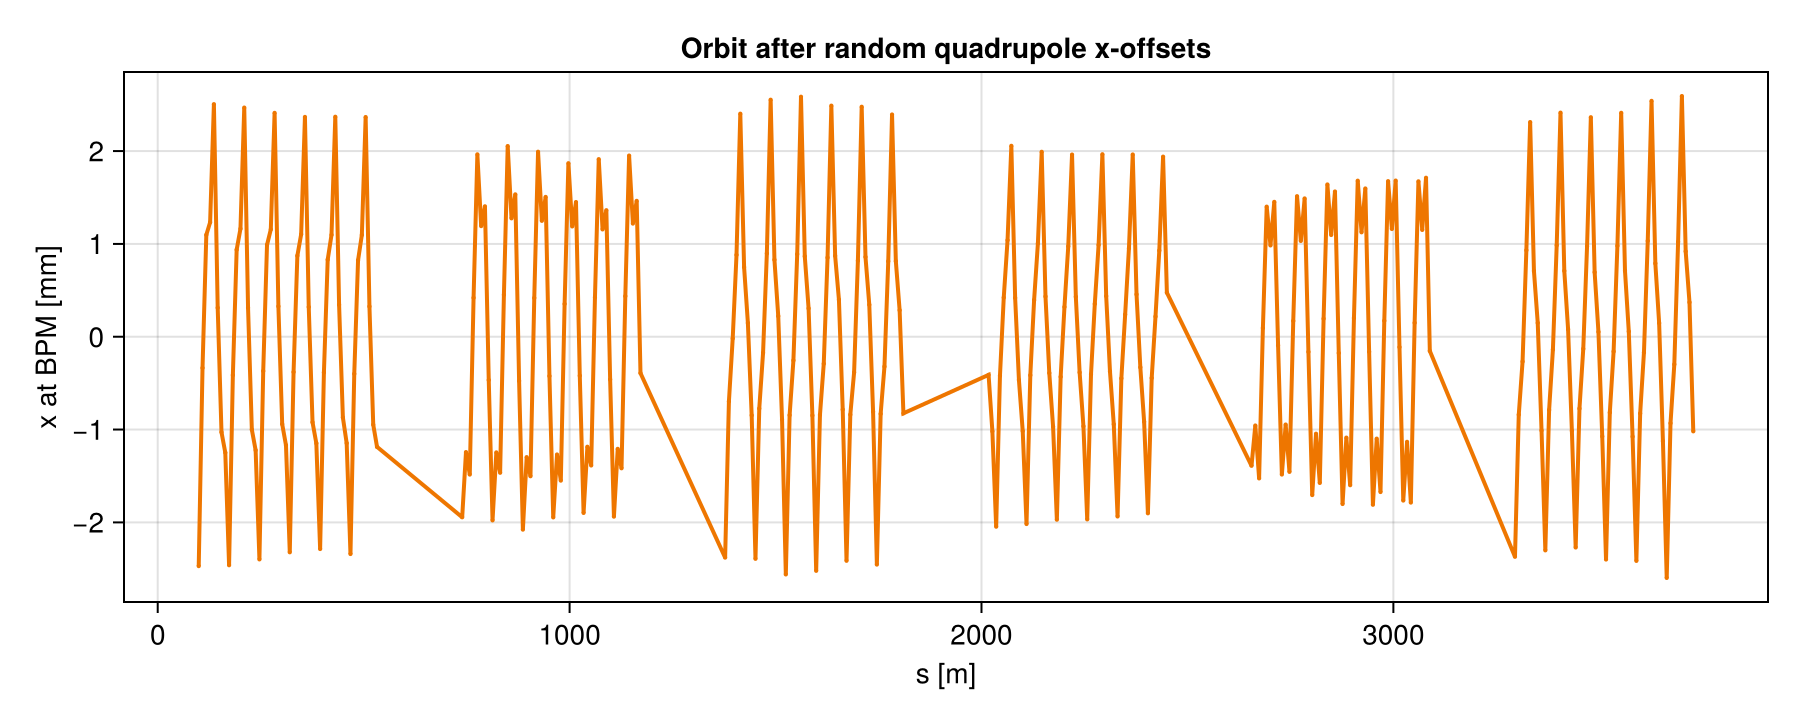

In [29]:
fig = Figure(size=(900, 360))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Orbit after random quadrupole x-offsets")
lines!(ax, bpm_s, 1e3 .* x_with_misalignment; color=:darkorange2, linewidth=2)
scatter!(ax, bpm_s, 1e3 .* x_with_misalignment; color=:darkorange2, markersize=3)
fig


### 15.3.2 Correct the Misalignment Orbit

For these small quadrupole offsets, the closed orbit remains usable. We compute a horizontal response matrix from the real converted ring with GTPSA, solve for additional horizontal corrector kicks, apply those kicks to the misaligned ring, and then read the corrected orbit again with tracking.


In [33]:
using GTPSA

function ch15_sbend_twiss_rows(ring, table)
    return [
        row for row in eachindex(table.beamline_index)
        if table.beamline_index[row] > 0 && ring.line[table.beamline_index[row]].kind == "SBend"
    ]
end

function ch15_gtpsa_horizontal_response_matrix(ring, bpm_rows, ch_indices; block_size=32)
    response = zeros(length(bpm_rows), length(ch_indices))

    for block_start in 1:block_size:length(ch_indices)
        block_stop = min(block_start + block_size - 1, length(ch_indices))
        ch_block = ch_indices[block_start:block_stop]

        descriptor = Descriptor(6, 1, length(ch_block), 1)
        kick_parameters = @params(descriptor, dynamic=true)

        gtpsa_ring = deepcopy(ring)
        for (j, ch_idx) in enumerate(ch_block)
            gtpsa_ring.line[ch_idx].Kn0L =
                TPS64(gtpsa_ring.line[ch_idx].Kn0L, use=descriptor) + kick_parameters[j]
        end

        gtpsa_table = twiss(gtpsa_ring, GTPSA_descriptor=descriptor).table
        response[:, block_start:block_stop] .= [
            gtpsa_table.orbit_x[bpm_rows[i]][params=[j => 1]]
            for i in eachindex(bpm_rows), j in eachindex(ch_block)
        ]

        @printf("Computed GTPSA response columns %d:%d / %d\n",
            block_start, block_stop, length(ch_indices))
    end

    return response
end

response_reference_table = twiss(corrected_ring).table
response_bpm_rows = ch15_sbend_twiss_rows(corrected_ring, response_reference_table)

misalignment_response = ch15_gtpsa_horizontal_response_matrix(
    corrected_ring,
    response_bpm_rows,
    ch_indices;
    block_size=32,
)

misalignment_regularization = 0.1
misalignment_kicks = -(misalignment_response' * misalignment_response + misalignment_regularization * I) \
    (misalignment_response' * x_with_misalignment)

misalignment_corrected_ring = deepcopy(misaligned_ring)
for (ch_idx, kick) in zip(ch_indices, misalignment_kicks)
    misalignment_corrected_ring.line[ch_idx].Kn0L += kick
end

misalignment_corrected_readback = ch15_closed_orbit_readback(
    misalignment_corrected_ring,
    bpm_indices;
    v0=misaligned_readback.closed_orbit,
)

x_misalignment_corrected = misalignment_corrected_readback.x
misalignment_solution = (;
    kicks = misalignment_kicks,
    corrected_x = x_misalignment_corrected,
    response = misalignment_response,
)

total_ch_kicks_after_misalignment = solution.kicks + misalignment_solution.kicks

@printf("Horizontal BPM rms before correction: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_with_misalignment)))
@printf("Horizontal BPM rms after correction:  %.4f mm\n", 1e3 * sqrt(mean(abs2, x_misalignment_corrected)))
@printf("Largest additional CH kick: %.3e rad\n", maximum(abs, misalignment_solution.kicks))


Computed GTPSA response columns 1:32 / 207
Computed GTPSA response columns 33:64 / 207
Computed GTPSA response columns 65:96 / 207
Computed GTPSA response columns 97:128 / 207
Computed GTPSA response columns 129:160 / 207
Computed GTPSA response columns 161:192 / 207
Computed GTPSA response columns 193:207 / 207
Horizontal BPM rms before correction: 1.331 mm
Horizontal BPM rms after correction:  0.0325 mm
Largest additional CH kick: 8.832e-06 rad


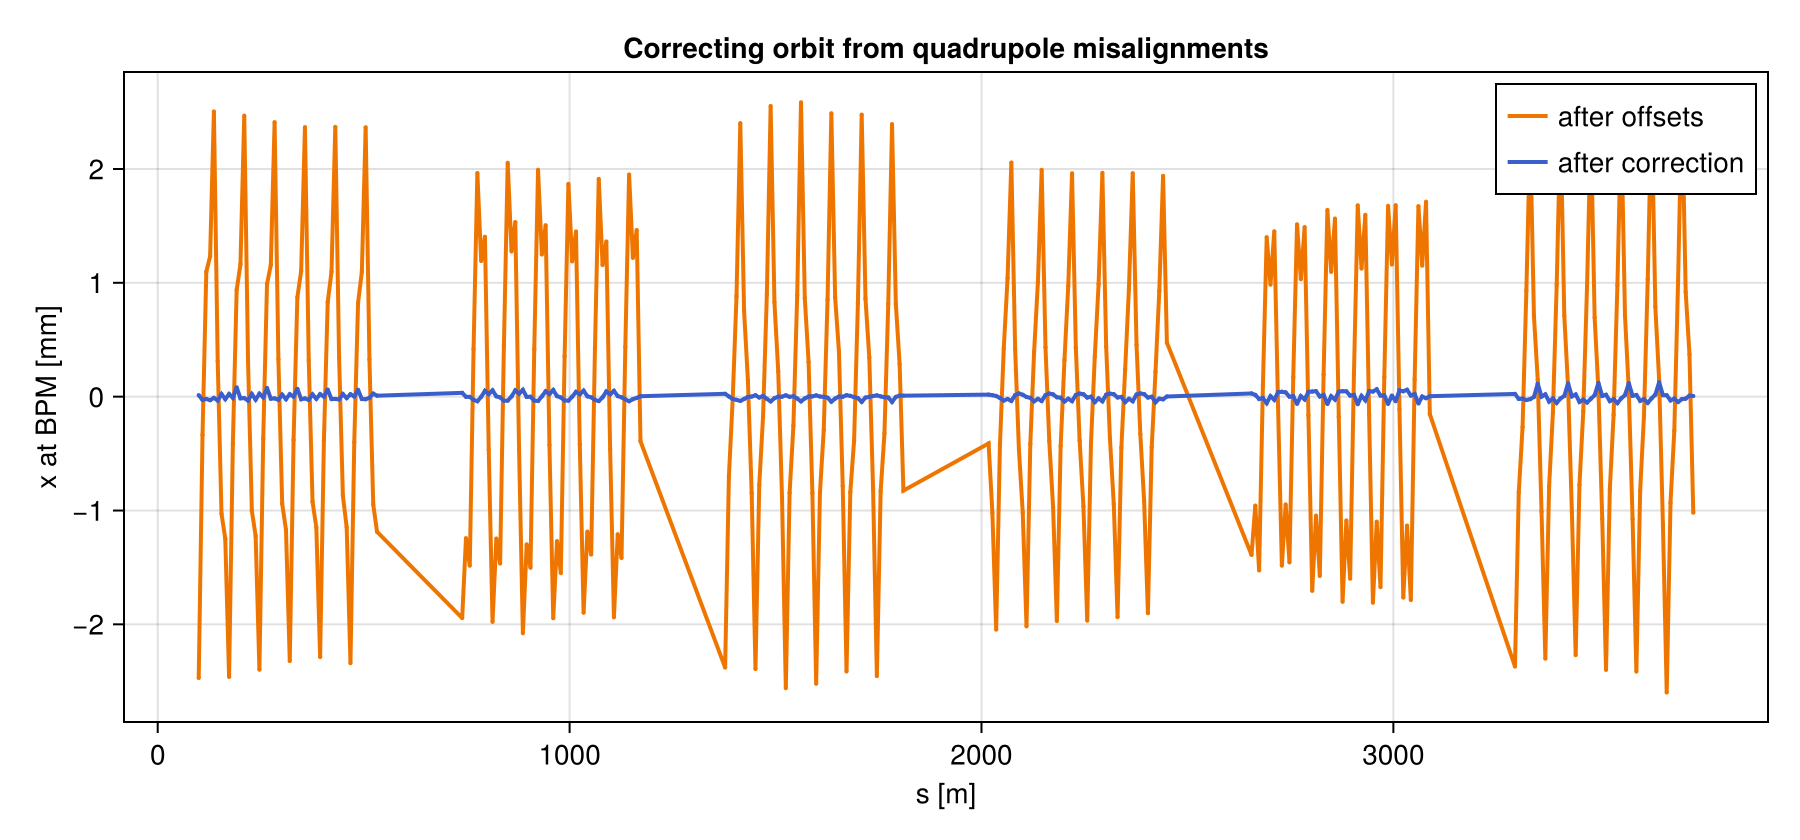

In [34]:
fig = Figure(size=(900, 420))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Correcting orbit from quadrupole misalignments")
lines!(ax, bpm_s, 1e3 .* x_with_misalignment; color=:darkorange2, linewidth=2, label="after offsets")
scatter!(ax, bpm_s, 1e3 .* x_with_misalignment; color=:darkorange2, markersize=3)
lines!(ax, bpm_s, 1e3 .* x_misalignment_corrected; color=:royalblue3, linewidth=2, label="after correction")
scatter!(ax, bpm_s, 1e3 .* x_misalignment_corrected; color=:royalblue3, markersize=3)
axislegend(ax; position=:rt)
fig


### 15.3.3 Large Misalignments Can Break a Closed-Orbit Correction

Now increase the quadrupole offsets to $\sigma_x = 100\,\mu\mathrm{m}$ and write those offsets into the real quadrupole elements. With offsets this large, the closed-orbit finder may fail before an optimizer has a usable orbit to correct.


In [35]:
function ch15_try_closed_orbit_readback(ring, readback_indices; v0=zeros(6))
    try
        readback = ch15_closed_orbit_readback(ring, readback_indices; v0)
        return (; failed=false, readback, error=nothing)
    catch err
        return (; failed=true, readback=nothing, error=err)
    end
end

large_quad_x_offsets = chapter15_truncated_gaussian(
    length(quad_indices);
    sigma=100e-6,
    cutoff=3.0,
    seed=144,
)

large_misaligned_ring = deepcopy(corrected_ring)
ch15_set_quadrupole_x_offsets!(large_misaligned_ring, large_quad_x_offsets)

large_readback_attempt = ch15_try_closed_orbit_readback(
    large_misaligned_ring,
    bpm_indices;
    v0=bpm_readback.closed_orbit,
)

large_closed_orbit_failed = large_readback_attempt.failed
large_closed_orbit_error = large_readback_attempt.error
large_misaligned_readback = large_readback_attempt.readback
x_large_closed_trial = large_closed_orbit_failed ? nothing : large_misaligned_readback.x

@printf("Large offset RMS: %.3f um\n", 1e6 * sqrt(mean(abs2, large_quad_x_offsets)))
@printf("Largest offset: %.3f um\n", 1e6 * maximum(abs, large_quad_x_offsets))

if large_closed_orbit_failed
    println("Large-misalignment closed-orbit readback failed before correction.")
    println("Error type: ", typeof(large_closed_orbit_error))
    println("Error: ", large_closed_orbit_error)
else
    @printf("Large-misalignment BPM rms before correction: %.3f mm\n",
        1e3 * sqrt(mean(abs2, x_large_closed_trial)))
    @printf("Large-misalignment max |x| before correction: %.3f mm\n",
        1e3 * maximum(abs, x_large_closed_trial))
end


┌ Warning: Particle lost in tracking
└ @ SciBmad C:\Users\JoeyN\.julia\packages\SciBmad\Cjbj1\src\SciBmad.jl:35
┌ Warning: Particle lost in tracking
└ @ SciBmad C:\Users\JoeyN\.julia\packages\SciBmad\Cjbj1\src\SciBmad.jl:35


Large offset RMS: 103.372 um
Largest offset: 298.674 um
Large-misalignment closed-orbit readback failed before correction.
Error type: SingularException
Error: SingularException(1)


No closed-orbit plot is shown here: for this random `100 μm` misalignment case, the closed-orbit readback fails before it produces BPM values to plot.


### 15.3.4 Correct the Orbit as an Open Lattice First

In SciBmad, the most common way to avoid starting from an unstable periodic orbit is to treat the ring as an open, single-pass lattice first. In this step we do not call `find_closed_orbit`. Instead, we track one particle through the misaligned ring once, record the orbit at the BPM readback locations, build a GTPSA single-pass response matrix from the horizontal correctors, and solve for kicks that reduce that single-pass orbit.


In [39]:
using GTPSA

# Track one particle through the lattice once, without imposing periodicity.
# This is the open-lattice orbit readback used when the closed orbit cannot be found.
function ch15_single_pass_readback(ring, readback_indices; initial=zeros(6))
    bunch = Bunch(reshape(copy(initial), (1, 6));
        p_over_q_ref=ring.p_over_q_ref,
        species=ring.species_ref,
    )

    readback_set = Set(readback_indices)
    x = Float64[]
    s = Float64[]
    names = String[]

    for (idx, ele) in pairs(ring.line)
        if idx in readback_set
            push!(x, Float64(bunch.coords.v[1]))
            push!(s, Float64(ele.s))
            push!(names, String(ele.name))
        end
        track!(bunch, ele)
    end

    return (; x, s, names)
end

# Build a single-pass response matrix with GTPSA.
# Each block treats a group of horizontal corrector Kn0L values as TPSA parameters.
function ch15_gtpsa_single_pass_response_matrix(ring, readback_indices, ch_indices; block_size=64, initial=zeros(6))
    response = zeros(length(readback_indices), length(ch_indices))

    for block_start in 1:block_size:length(ch_indices)
        block_stop = min(block_start + block_size - 1, length(ch_indices))
        ch_block = ch_indices[block_start:block_stop]

        # Six phase-space variables plus one parameter for each corrector in this block.
        descriptor = Descriptor(6, 1, length(ch_block), 1)
        kick_parameters = @params(descriptor, dynamic=true)

        # Put a TPSA parameter into each corrector strength in this block.
        gtpsa_ring = deepcopy(ring)
        for (j, ch_idx) in enumerate(ch_block)
            gtpsa_ring.line[ch_idx].Kn0L =
                TPS64(gtpsa_ring.line[ch_idx].Kn0L, use=descriptor) + kick_parameters[j]
        end

        # The tracked particle coordinates must use the same descriptor as the corrector parameters.
        initial_tps = [TPS64(initial[i], use=descriptor) for i in 1:6]
        bunch = Bunch(reshape(initial_tps, (1, 6));
            p_over_q_ref=gtpsa_ring.p_over_q_ref,
            species=gtpsa_ring.species_ref,
        )

        # Track once and read dx_BPM / dKn0L from the TPSA coefficient at each BPM.
        readback_set = Set(readback_indices)
        row = 0
        for (idx, ele) in pairs(gtpsa_ring.line)
            if idx in readback_set
                row += 1
                for j in eachindex(ch_block)
                    response[row, block_start + j - 1] = bunch.coords.v[1][params=[j => 1]]
                end
            end
            track!(bunch, ele)
        end

        @printf("Computed single-pass GTPSA response columns %d:%d / %d\n",
            block_start, block_stop, length(ch_indices))
    end

    return response
end

# Start from the large-error ring that could not produce a closed orbit.
open_stage_ring = deepcopy(large_misaligned_ring)
x_large_single_pass = ch15_single_pass_readback(open_stage_ring, bpm_indices).x
x_open_stage_initial = copy(x_large_single_pass)

# Correct the open-lattice orbit iteratively. Recomputing the response after each step
# keeps the linear model close to the current trajectory.
open_stage_regularization = 0.1
open_stage_iterations = 4
open_stage_total_kicks = zeros(length(ch_indices))
open_stage_history = NamedTuple[]

for iter in 1:open_stage_iterations
    x_before_iter = ch15_single_pass_readback(open_stage_ring, bpm_indices).x
    response_iter = ch15_gtpsa_single_pass_response_matrix(
        open_stage_ring,
        bpm_indices,
        ch_indices;
        block_size=64,
    )

    kick_step = -(response_iter' * response_iter + open_stage_regularization * I) \
        (response_iter' * x_before_iter)

    for (ch_idx, kick) in zip(ch_indices, kick_step)
        open_stage_ring.line[ch_idx].Kn0L += kick
    end

    open_stage_total_kicks .+= kick_step
    x_after_iter = ch15_single_pass_readback(open_stage_ring, bpm_indices).x

    push!(open_stage_history, (;
        iteration = iter,
        rms = sqrt(mean(abs2, x_after_iter)),
        max_abs = maximum(abs, x_after_iter),
        max_step_kick = maximum(abs, kick_step),
    ))
end

open_stage_readback = ch15_single_pass_readback(open_stage_ring, bpm_indices)
open_stage_solution = (;
    kicks = open_stage_total_kicks,
    corrected_x = open_stage_readback.x,
    history = open_stage_history,
)

@printf("Single-pass rms before open correction: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_open_stage_initial)))
for item in open_stage_history
    @printf("  iteration %d rms: %.3f mm, max |x|: %.3f mm, max step kick: %.3e rad\n",
        item.iteration, 1e3 * item.rms, 1e3 * item.max_abs, item.max_step_kick)
end
@printf("Single-pass rms after open correction:  %.3f mm\n", 1e3 * sqrt(mean(abs2, open_stage_solution.corrected_x)))
@printf("Largest accumulated open-stage CH kick: %.3e rad\n", maximum(abs, open_stage_solution.kicks))


Computed single-pass GTPSA response columns 1:64 / 207
Computed single-pass GTPSA response columns 65:128 / 207
Computed single-pass GTPSA response columns 129:192 / 207
Computed single-pass GTPSA response columns 193:207 / 207
Computed single-pass GTPSA response columns 1:64 / 207
Computed single-pass GTPSA response columns 65:128 / 207
Computed single-pass GTPSA response columns 129:192 / 207
Computed single-pass GTPSA response columns 193:207 / 207
Computed single-pass GTPSA response columns 1:64 / 207
Computed single-pass GTPSA response columns 65:128 / 207
Computed single-pass GTPSA response columns 129:192 / 207
Computed single-pass GTPSA response columns 193:207 / 207
Computed single-pass GTPSA response columns 1:64 / 207
Computed single-pass GTPSA response columns 65:128 / 207
Computed single-pass GTPSA response columns 129:192 / 207
Computed single-pass GTPSA response columns 193:207 / 207
Single-pass rms before open correction: 4.464 mm
  iteration 1 rms: 0.985 mm, max |x|: 4

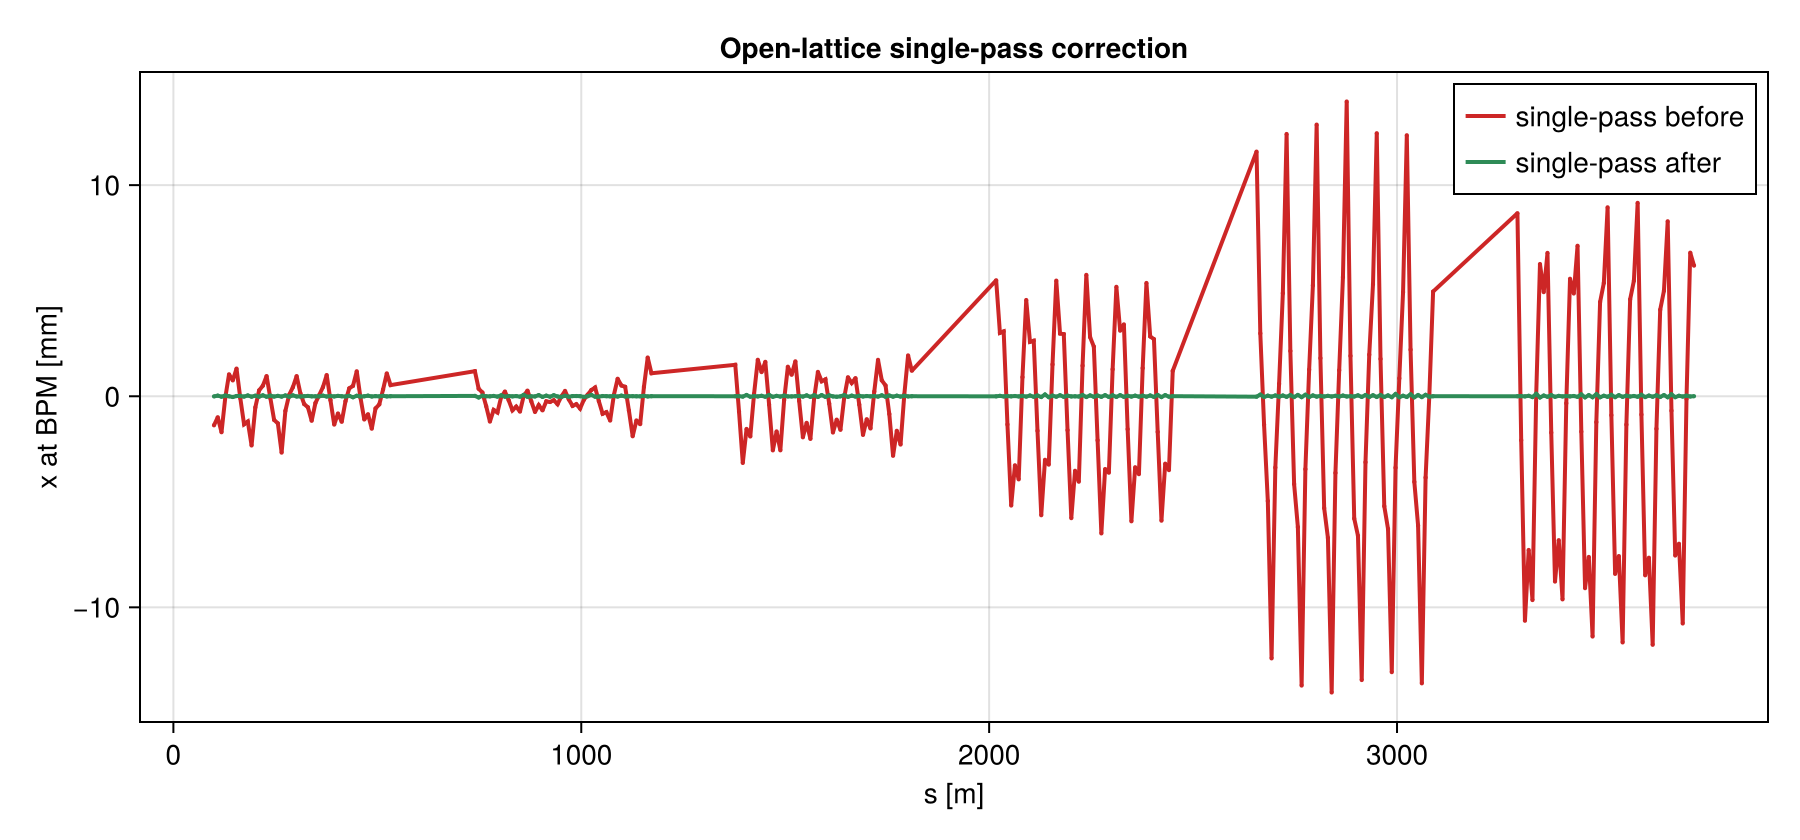

In [40]:
fig = Figure(size=(900, 420))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Open-lattice single-pass correction")
lines!(ax, bpm_s, 1e3 .* x_open_stage_initial; color=:firebrick3, linewidth=2, label="single-pass before")
scatter!(ax, bpm_s, 1e3 .* x_open_stage_initial; color=:firebrick3, markersize=3)
lines!(ax, bpm_s, 1e3 .* open_stage_solution.corrected_x; color=:seagreen4, linewidth=2, label="single-pass after")
scatter!(ax, bpm_s, 1e3 .* open_stage_solution.corrected_x; color=:seagreen4, markersize=3)
axislegend(ax; position=:rt)
fig


### 15.3.5 Switch Back to Closed-Orbit Correction

After the open-lattice correction has reduced the single-pass trajectory, try the closed-orbit readback again. If a periodic orbit can now be found, compute a closed-orbit GTPSA response matrix for the open-corrected ring and use it for a final closed-orbit correction.


In [41]:
open_stage_closed_attempt = ch15_try_closed_orbit_readback(
    open_stage_ring,
    bpm_indices;
    v0=bpm_readback.closed_orbit,
)

if open_stage_closed_attempt.failed
    error("The open-stage correction did not recover a readable closed orbit: " * string(open_stage_closed_attempt.error))
end

x_after_open_stage_closed = open_stage_closed_attempt.readback.x

open_stage_twiss_table = twiss(open_stage_ring).table
open_stage_bpm_rows = ch15_sbend_twiss_rows(open_stage_ring, open_stage_twiss_table)
closed_stage_response = ch15_gtpsa_horizontal_response_matrix(
    open_stage_ring,
    open_stage_bpm_rows,
    ch_indices;
    block_size=64,
)

closed_stage_regularization = 10.0
closed_stage_kicks = -(closed_stage_response' * closed_stage_response + closed_stage_regularization * I) \
    (closed_stage_response' * x_after_open_stage_closed)

closed_stage_ring = deepcopy(open_stage_ring)
for (ch_idx, kick) in zip(ch_indices, closed_stage_kicks)
    closed_stage_ring.line[ch_idx].Kn0L += kick
end

closed_stage_readback = ch15_closed_orbit_readback(
    closed_stage_ring,
    bpm_indices;
    v0=open_stage_closed_attempt.readback.closed_orbit,
)

x_large_staged_corrected = closed_stage_readback.x
closed_polish_solution = (;
    kicks = closed_stage_kicks,
    corrected_x = x_large_staged_corrected,
    response = closed_stage_response,
)

large_total_ch_kicks = solution.kicks + open_stage_solution.kicks + closed_polish_solution.kicks

@printf("Closed-orbit rms after open stage: %.3f mm\n", 1e3 * sqrt(mean(abs2, x_after_open_stage_closed)))
@printf("Closed-orbit rms after closed correction: %.4f mm\n", 1e3 * sqrt(mean(abs2, x_large_staged_corrected)))
@printf("Closed-orbit max |x| after closed correction: %.3f mm\n", 1e3 * maximum(abs, x_large_staged_corrected))
@printf("Largest additional closed-stage CH kick: %.3e rad\n", maximum(abs, closed_polish_solution.kicks))
@printf("Largest accumulated CH kick after staged correction: %.3e rad\n", maximum(abs, large_total_ch_kicks))


Computed GTPSA response columns 1:64 / 207
Computed GTPSA response columns 65:128 / 207
Computed GTPSA response columns 129:192 / 207
Computed GTPSA response columns 193:207 / 207
Closed-orbit rms after open stage: 0.445 mm
Closed-orbit rms after closed correction: 0.0799 mm
Closed-orbit max |x| after closed correction: 0.208 mm
Largest additional closed-stage CH kick: 5.451e-05 rad
Largest accumulated CH kick after staged correction: 8.759e-05 rad


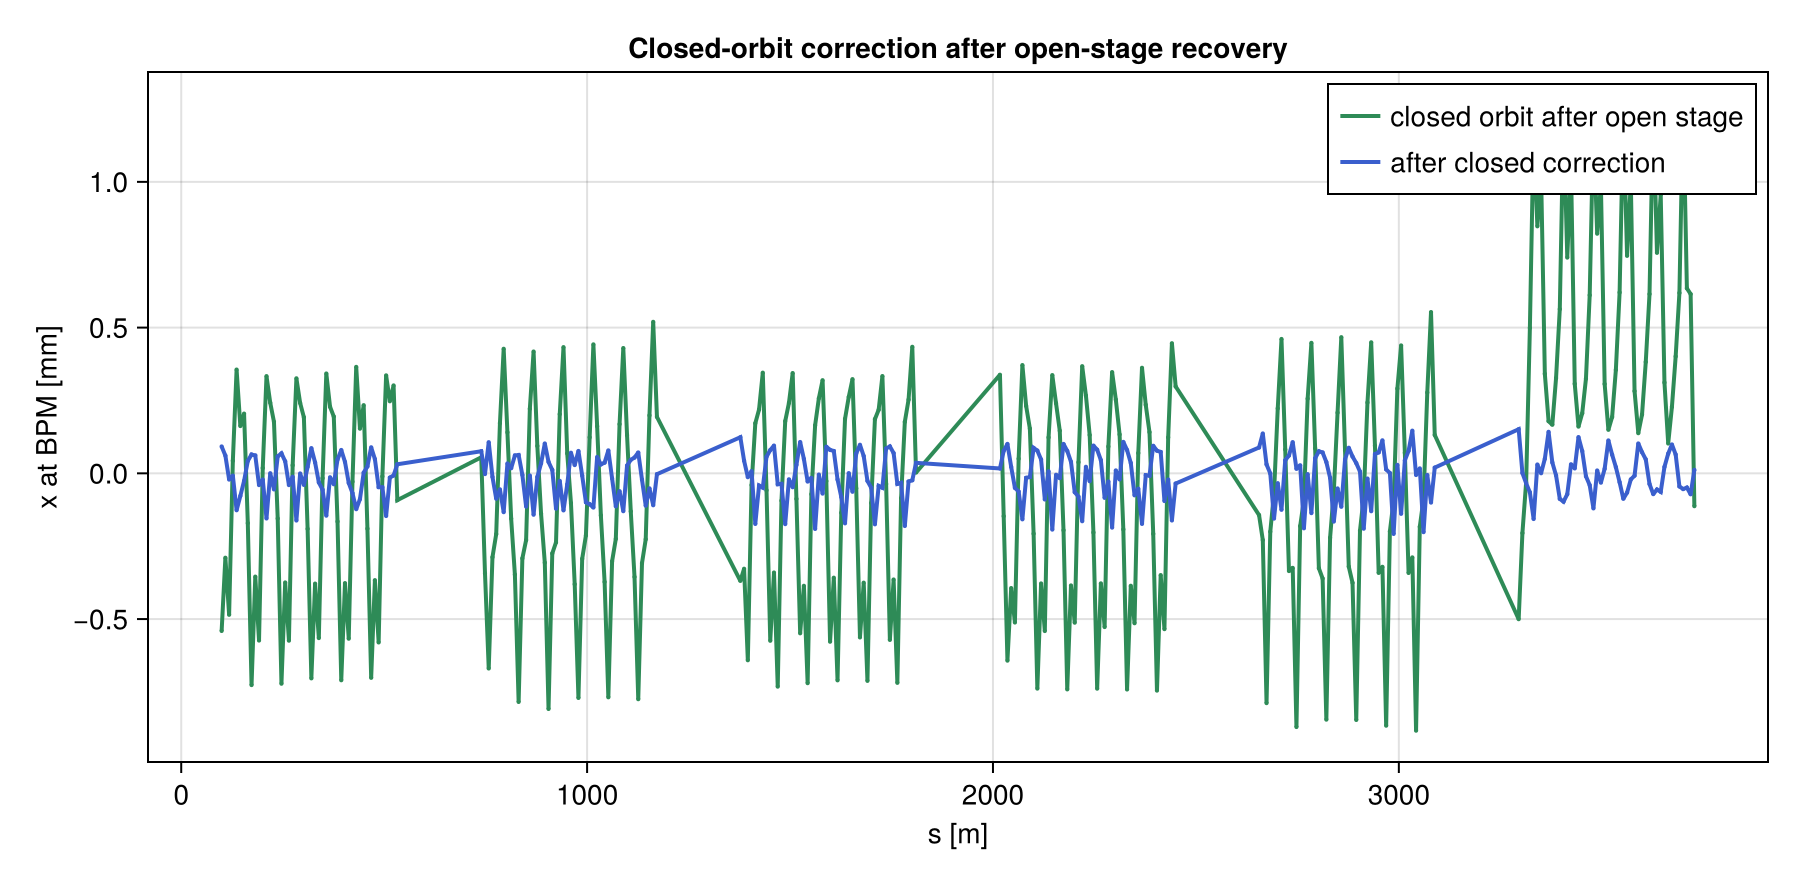

In [42]:
fig = Figure(size=(900, 440))
ax = Axis(fig[1, 1], xlabel="s [m]", ylabel="x at BPM [mm]", title="Closed-orbit correction after open-stage recovery")
lines!(ax, bpm_s, 1e3 .* x_after_open_stage_closed; color=:seagreen4, linewidth=2, label="closed orbit after open stage")
scatter!(ax, bpm_s, 1e3 .* x_after_open_stage_closed; color=:seagreen4, markersize=3)
lines!(ax, bpm_s, 1e3 .* x_large_staged_corrected; color=:royalblue3, linewidth=2, label="after closed correction")
scatter!(ax, bpm_s, 1e3 .* x_large_staged_corrected; color=:royalblue3, markersize=3)
axislegend(ax; position=:rt)
fig


### 15.3.6 Alternative Method: Add a Stability Penalty

Another way to avoid unstable closed-orbit solutions is to add a stability penalty to the optimizer objective. This plays the same role as Tao's `unstable.lattice` datum: if a candidate orbit is stable, the penalty is zero; if the closed orbit is unstable or outside the acceptable region, the penalty is positive and the optimizer is pushed away from that candidate.

Here the penalty is shown explicitly as a score term. In a full SciBmad optimization, this same idea would be evaluated inside the objective function while the optimizer varies the corrector strengths.

However, as there isn't a datum called `unstable.lattice` that can be directly used in SciBmad, this method cannot be directly used in SciBmad and it is put here just for reference.

In [43]:
function chapter15_penalized_orbit_score(x_bpm, kicks; max_allowed=5e-3, kick_weight=1e-4, unstable_weight=1.0)
    check = chapter15_orbit_stability_check(x_bpm; max_allowed)
    orbit_term = mean(abs2, x_bpm)
    kick_term = kick_weight * mean(abs2, kicks)
    unstable_term = unstable_weight * check.penalty
    return (; score=orbit_term + kick_term + unstable_term, orbit_term, kick_term, unstable_term, check)
end

penalty_candidates = [
    ("large closed trial", x_large_closed_trial, zeros(length(ch_s))),
    ("after open stage", x_after_open_stage_closed, open_stage_solution.kicks),
    ("after closed polish", x_large_staged_corrected, open_stage_solution.kicks + closed_polish_solution.kicks),
]

println(rpad("candidate", 22), rpad("rms [mm]", 12), rpad("max [mm]", 12), rpad("penalty", 12), "score")
for (label, orbit, kicks) in penalty_candidates
    scored = chapter15_penalized_orbit_score(orbit, kicks; max_allowed=5e-3, unstable_weight=1.0)
    @printf(
        "%-22s%-12.3f%-12.3f%-12.3e%.3e\n",
        label,
        1e3 * scored.check.rms,
        1e3 * scored.check.max_abs,
        scored.unstable_term,
        scored.score,
    )
end

candidate             rms [mm]    max [mm]    penalty     score
large closed trial    7.137       13.011      2.567e+00   2.567e+00
after open stage      0.359       1.112       0.000e+00   1.292e-07
after closed polish   0.135       1.180       0.000e+00   1.824e-08


## 15.4 Exercise: Zero Orbit at the IP

Use the four horizontal correctors `CH_104` through `CH_107` and the four vertical correctors `CV_104` through `CV_107` to make the orbit exactly zero at the IP without affecting the rest of the ring.

This is a local bump problem. The two upstream kickers set the orbit at the IP, and the two downstream kickers close the bump so the orbit and angle return to their original values after the IP region. In other words, solve for the eight kicker strengths so that:

- at the IP, the horizontal and vertical orbit errors are corrected;
- after the local bump region, the orbit and angle return to their original values;
- outside the bump region, the ring orbit is unchanged.

The solution script for this exercise is stored in `lattices/chapter_15/15_4_exercise_solution/chapter15_local_bump_exercise.jl`, and the generated result is stored in `lattices/chapter_15/15_4_exercise_solution/chapter15_local_bump_solution.jl`.
